# Behavioral Analysis - Day 3: social recognition memory

This notebook processes EthoVision output files from the three-chamber social interaction paradigm to quantify **social recognition memory** in Alzheimer's Disease (AD) mice and control mice. The analysis focuses on **Day 3** of the experiment, where one cup contains the familiar mouse from day 2 (familiar stimulus) and the other cup contains a new mouse (novel stimulus). 

Social recognition memory is found using a social novelty index, which was calculated as follows:

$SNI = \frac{t_{novel} - t_{familiar}}{t_{novel} + t_{familiar}}$

where $t_{novel}$ is the time spent investigating the novel stimulus (the new, unfamiliar mouse), and $t_{familiar}$ is the time spent investigating the familiar stimulus (the mouse introduced on day 2). 

Values: 
- **Above 0**: Preference for novel stimulus, which indicates intact social recognition memory
- **Below 0**: Preference for familiar stimulus
- **0**: No preference 

The following steps are taken to get the social novelty index for the different groups (3xTg males, 3xTg females, Ntg control males, Ntg control females):
1. For each Excel file (EthoVision output files, corresponding to a specific mouse): 
    * Metadata is read 
    * Animal ID, genotype, sex, batch, and the side on which the stimulus mouse was placed is identified 
2. Identify relevant time periods in excel sheets  (each sheet contains periods of investigation in regions of interest)
    * Calculate how much time each animal spent with its nose-point in 
        * the left and right cup zones,
        * surrounding cup zones, and 
        * chamber zones
3. Sum up the investigation time periods 
    * Convert measurements into time spent investigating novel mouse cup and time spent investigating familiar mouse cup 
4. Visualize social novelty measures 
5. Calculate a discrimination index for each mouse
6. Find the average discrimination index for each group 
7. Visualize findings 
8. Perform statistical analyses to find out whether the differences between groups are significant 

Next to finding the discrimination index, **total investigation time** is also calculated. 
Analysis is very similar to Day 2, but instead of a social and non-social stimulus, there is a novel and familiar stimulus. 

## 0. Preparation

### 0.1. Load all relevant libraries

In [1]:
import pandas as pd
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import math 

# Find the project root folder that contains mrondes_files
project_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "mrondes_files").is_dir()
)

# Add project root to Python path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
print("Project root:", project_root)

from mrondes_files.helper_functions import select_folder

# Statistical testing
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

Project root: /Users/febevansommeren/Documents/Social behavior in mice


### 0.2. Define file paths

In [2]:
PROJECT_DIR = project_root
print(PROJECT_DIR)

# excel sheets
DATA_DIR = select_folder("select folder containing the behavioral results (excel sheets)")
print(DATA_DIR)

# Output folder
OUTPUT_DIR = select_folder("select or create a folder to save all results in")

/Users/febevansommeren/Documents/Social behavior in mice
/Users/febevansommeren/Documents/Social behavior in mice/excel files/day 3


### 0.3. Set some global variables

In [3]:
OUTPUT_COLUMNS = [
    'Time spent in zone right cup',
    'Time spent in zone left cup',
    'Time spent surrounding right cup',
    'Time spent surrounding left cup',
    'Time spent in zone right chamber',
    'Time spent in zone middle chamber',
    'Time spent in zone left chamber',
    'Animal ID',
    'Animal info',
    'Genotype',
    'Sex',
    'Batch',
    'Time spent in zone with novel mouse',
    'Time spent in zone with familiar mouse',
    'Time spent surrounding novel mouse',
    'Time spent surrounding familiar mouse'
]

# WITH ADJUSTED FPS
ANIMAL_TRIAL_TIME_BOUNDARIES = {
    '8989': (4, 601),
    '8993': (7, 609),
    '8982': (22, 674),
    '8995': (10, 612),
    '8990': (6, 657),
    '8903': (4, 606),
    '8998': (1, 652),
    '8981': (4, 605),
    '8987': (4, 605),
    '8988': (2, 537),
    '8996': (6, 607),
    '8994': (5, 607),
    '8983': (5, 606), 
    '8992': (3, 605),
    '8985': (3, 605),
    '8997': (3, 605),
    '9000': (4, 605),
    '9001': (1, 603),
    '9007': (0, 602),
    '9002': (3, 605),
    '9005': (3, 605),
    '9012': (2, 604),
    '9010': (5, 606),
    '9020': (6, 608),
    '9003': (5, 606),
    '8991': (3, 605),
    '8986': (2, 603), 
    '9013': (3, 605),
    '9017': (1, 603),
    '9019': (3, 604), 
    '9009': (1, 602),
    '9008': (1, 602),
    '9018': (4, 609),
    '9004': (0, 602),
    '9014': (4, 605),
    '9016': (1, 604),
    '9011': (3, 605),
    '8858': (1, 621),
    '8760': (1, 603),
    '8851': (1, 603),
    '8859': (1, 606),
    '8857': (1, 603),
    '8854': (1, 602),
    '8855': (1, 602),
    '9015': (1, 603),
}


# Define column patterns for each zone
ZONE_COLUMNS = {
    'right_cup': [
        'In zone(Right Cup / Nose-point)',
        'In zone(right cup 2 / Nose-point)',
        'In zone(right cup 3 / Nose-point)',
        'In zone(right cup 1 / Nose-point)'
        ],
    'left_cup': [
        'In zone(Left Cup / Nose-point)',
        'In zone(left cup 2 / Nose-point)',
        'In zone(left cup 3 / Nose-point)',
        'In zone(Left Cup 1 / Nose-point)'
    ],
    'right_cup_zone': [
        'In zone(Right Cup Zone / Nose-point)',
        'In zone(right cup zone 2 / Nose-point)',
        'In zone(right cup zone 3 / Nose-point)',
        'In zone(Right Cup Zone 1 / Nose-point)'
    ],
    'left_cup_zone': [
        'In zone(Left Cup Zone / Nose-point)',
        'In zone(left cup zone 2 / Nose-point)',
        'In zone(Left cup zone 3 / Nose-point)',
        'In zone(Left Cup Zone 1 / Nose-point)'
    ],
    'right_chamber': [
        'In zone(Right Chamber / Nose-point)',
        'In zone(right chamber 2 / Nose-point)',
        'In zone(right chamber 3 / Nose-point)',
        'In zone(Right Chamber 1 / Nose-point)'
    ],
    'middle_chamber': [
        'In zone(Middle Chamber / Nose-point)',
        'In zone(middle chamber 2 / Nose-point)',
        'In zone(middle chamber 3 / Nose-point)',
        'In zone(Middle Chamber 1 / Nose-point)'
    ],
    'left_chamber': [
        'In zone(Left Chamber / Nose-point)',
        'In zone(left chamber 2 / Nose-point)',
        'In zone(left chamber 3 / Nose-point)',
        'In zone(Left Chamber 1 / Nose-point)'
    ]
}

### 0.4. Define helper functions

In [4]:
def calculate_time_in_zones(zone_keywords, trial_window, fps=30):
    """
    Calculates the total time spent in a zone matching the given keywords during a trial window. 

    Parameters: 
    ### zone_keywords [list[str]]: Keywords used to identify the relevant zone columns in the EthoVision
        output. 
    ### trial_window [pandas.DataFrame]:  DataFrame containing the EthoVision tracking data for the relevant
        trial period. Columns should include binary zone indicators, where 1 means the animal was detected in 
        that zone during a given frame.
    ### fps [int | float]: Frames per second of the video recording. The default is 30 fps.
    Returns: 
    ### total_time [float]: Total time spent in the matching zone columns in seconds.
    """
    total_time = 0
    for keyword in zone_keywords:
        matching_cols = [col for col in trial_window.columns if keyword.lower() in col.lower()]
        if matching_cols:
            total_time += (trial_window[matching_cols] == 1).sum().sum()
    return total_time / fps  

def add_derived_measures(df):
    """
    Add social novelty-related measures to the dataframe.

    This function calculates the discrimination index and total investigation
    time for each mouse based on the time spent investigating the novel and
    familiar stimulus zones.

    Parameters:
    ### df [pandas.DataFrame]: DataFrame containing time spent in the zone with the novel mouse and
        time spent in the zone with the familiar mouse.

    Returns:
    ### df [pandas.DataFrame]: Copy of the input dataframe with two added columns:
        'discrimination index' and 'total investigation time'.
    """

    df = df.copy()

    with_novel_mouse = pd.to_numeric(df["Time spent in zone with novel mouse"], errors="coerce")
    with_familiar_mouse = pd.to_numeric(df["Time spent in zone with familiar mouse"], errors="coerce")

    total = with_novel_mouse + with_familiar_mouse
    df["discrimination index"] = np.where(
        total == 0,
        np.nan,
        (with_novel_mouse - with_familiar_mouse) / total,
    )
    df["total investigation time"] = total

    return df

## 1 - 3. Process EthoVision files 

In [5]:
def process_behavioral_data(folder_path):
    """
    Process Day 3 EthoVision Excel files and extract social novelty measures.

    For each valid Excel file, this function reads the metadata and tracking data,
    selects the relevant trial window, calculates time spent in predefined zones,
    and converts left/right cup measurements into time spent with novel and familiar
    stimulus mouse.

    Parameters:
    ### folder_path [str]: Path to the folder containing the EthoVision Excel files.

    Returns:
    ### etho_3c_memory_df [pandas.DataFrame]: Summary dataframe with metadata and 
        zone-based time measures for each mouse.
    """

    rows = []
    # Loop through all Excel files
    for filename in os.listdir(folder_path):
        if filename.endswith('.xlsx'):
            file_path = os.path.join(folder_path, filename)
            metadata_df = pd.read_excel(file_path, header=None)

            # Check if the file has enough rows before accessing specific metadata
            if metadata_df.shape[0] < 41: ## B41 needs to be accessed 
                print(f"Skipping '{filename}' - metadata too short (only {metadata_df.shape[0]} rows)")
                continue 

            # Check if it is Day 3
            day_info = metadata_df.iloc[37, 1]  # B38
            if str(day_info).strip() != '3':
                print(f"Skipping '{filename}' - Day info is not '3' (got '{day_info}')")
                continue

            # Read data starting from row 43 (Excel row 42 + 1)
            trial_df = pd.read_excel(file_path, header=42, thousands=',') 
            trial_df.columns = trial_df.columns.str.strip()

            # handle missing values:
            trial_df = trial_df.fillna(0)  # Fills all NaN values with 0

            # Access 'Trial time' using column index 0 (column A)
            trial_df.iloc[:, 0] = pd.to_numeric(trial_df.iloc[:, 0], errors='coerce')
            trial_df['Trial time'] = trial_df.iloc[:, 0]  # Rename for consistent use

            animal_id = str(metadata_df.iloc[34, 1]).strip()  # B35

            if animal_id not in ANIMAL_TRIAL_TIME_BOUNDARIES:
                print(f"Warning: No trial time boundaries found for Animal ID '{animal_id}' in filename '{filename}'")
                continue
            
            # Define trial start and end time 
            trial_time_start, trial_time_end = ANIMAL_TRIAL_TIME_BOUNDARIES[animal_id]
            trial_window_df = trial_df[
                        (trial_df['Trial time'] >= trial_time_start) & 
                        (trial_df['Trial time'] <= trial_time_end)
                    ] 

            # Get time spent in zones
            right_cup = calculate_time_in_zones(ZONE_COLUMNS['right_cup'], trial_window_df)
            left_cup = calculate_time_in_zones(ZONE_COLUMNS['left_cup'], trial_window_df)
            right_cup_zone = calculate_time_in_zones(ZONE_COLUMNS['right_cup_zone'], trial_window_df)
            left_cup_zone = calculate_time_in_zones(ZONE_COLUMNS['left_cup_zone'], trial_window_df)
            right_chamber = calculate_time_in_zones(ZONE_COLUMNS['right_chamber'], trial_window_df)
            middle_chamber = calculate_time_in_zones(ZONE_COLUMNS['middle_chamber'], trial_window_df)
            left_chamber = calculate_time_in_zones(ZONE_COLUMNS['left_chamber'], trial_window_df)
            
            # Sum total surrounding times
            surrounding_right_cup = right_cup + right_cup_zone
            surrounding_left_cup = left_cup + left_cup_zone

            # Identify cup position
            cup_position = str(metadata_df.iloc[39, 1]).strip() # B40 shows place novel mouse

            # Rename to with novel/familiar mouse from cup position
            if cup_position == 'L':
                time_spent_with_novel = left_cup
                time_spent_with_familiar = right_cup 
                surrounding_novel = surrounding_left_cup
                surrounding_familiar = surrounding_right_cup
            elif cup_position == 'R':
                time_spent_with_novel = right_cup
                time_spent_with_familiar = left_cup
                surrounding_novel = surrounding_right_cup
                surrounding_familiar = surrounding_left_cup
            else:
                print(f"Invalid cup position '{cup_position}' in file '{filename}', skipping...")
                continue  # Skip if L/R unclear

            # Metadata
            animal_info = metadata_df.iloc[10, 1]  # B11
            genotype = metadata_df.iloc[35, 1]     # B36
            sex = metadata_df.iloc[36, 1]          # B37
            batch = metadata_df.iloc[40, 1]        # B41

            rows.append({
                'Time spent in zone right cup': right_cup,
                'Time spent in zone left cup': left_cup,
                'Time spent surrounding right cup': surrounding_right_cup,
                'Time spent surrounding left cup': surrounding_left_cup,
                'Time spent in zone right chamber': right_chamber,
                'Time spent in zone middle chamber': middle_chamber,
                'Time spent in zone left chamber': left_chamber,
                'Animal ID': animal_id,
                'Animal info': animal_info,
                'Genotype': genotype,
                'Sex': sex,
                'Batch': batch,
                'Time spent in zone with novel mouse': time_spent_with_novel,
                'Time spent in zone with familiar mouse': time_spent_with_familiar,
                'Time spent surrounding novel mouse': surrounding_novel,
                'Time spent surrounding familiar mouse': surrounding_familiar
            })

    etho_3c_memory_df = pd.DataFrame(rows, columns=OUTPUT_COLUMNS)    
    return etho_3c_memory_df

In [6]:
def get_behavior_results(data_folder, output_folder): # EDIT
    """
    Process EthoVision files and save the Day 3 behavioral results.

    Parameters:
    ### data_folder [str]: Path to the folder containing the EthoVision Excel files.
    ### output_folder [str]: Path to the folder where the results file should be saved.

    Returns:
    ### df [pandas.DataFrame]: Summary dataframe containing Day 3 behavioral measures for each mouse.
    """
    df = process_behavioral_data(data_folder)

    # Save to Excel
    output_file = os.path.join(output_folder, 'behavior_results_day3.xlsx')
    df.to_excel(output_file, index=False)

    print(df.head())
    return df

#### Generate behavioral results dataframe

In [7]:
etho_3c_memory_df = get_behavior_results(DATA_DIR, OUTPUT_DIR)

   Time spent in zone right cup  Time spent in zone left cup  \
0                    138.200000                    56.133333   
1                    191.666667                    53.400000   
2                     60.966667                    81.166667   
3                     82.666667                   141.466667   
4                     85.300000                    77.266667   

   Time spent surrounding right cup  Time spent surrounding left cup  \
0                        192.466667                       170.366667   
1                        257.600000                       108.400000   
2                         99.133333                       123.800000   
3                        143.000000                       199.833333   
4                        101.633333                        77.266667   

   Time spent in zone right chamber  Time spent in zone middle chamber  \
0                         11.366667                          81.433333   
1                         50.26666

## 4. Visualize social novelty measures

In [11]:
def prep_mem_measures_for_plotting(df):
    """
    Prepare social novelty time measures for plotting by
    * creating a combined group label from sex and genotype,
    * converts selected time-measure columns to numeric values, and 
    * reshapes the dataframe from wide to long format.

    Parameters:
    ### df [pandas.DataFrame]: DataFrame containing social novelty-related time measures and metadata.

    Returns:
    metled_group [pandas.DataFrame]: Long-format dataframe with group, measure, and time columns for plotting.
    """
    # Combine Sex and Genotype into one column for grouping
    df['Group'] = df['Sex'].astype(str).str.capitalize() + ' ' + df['Genotype'].astype(str)

    # Ensure values are numeric
    cols_to_numeric = [
        'Time spent in zone with novel mouse',
        'Time spent in zone with familiar mouse',
        'Time spent surrounding novel mouse',
        'Time spent surrounding familiar mouse'
    ]
    df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

    # Melt the DataFrame to long format
    melted_group = pd.melt(
        df,
        id_vars=['Group'],
        value_vars=cols_to_numeric,
        var_name='Measure',
        value_name='Time'
    )

    return melted_group


def create_plot_social_memory_measures(dataframe, output_dir):
    """
    Creates and shows plot of social novelty time measures  

    Parameters
    ### dataframe [pandas.DataFrame]: Long-format dataframe containing group labels, 
        time measures, and time values.
    ### output_dir [str]: directory for output 

    Returns:
    # None: when running the function, it will save and show the plot 

    """
    # Set plotting style
    sns.set(style="whitegrid")

    # Create the plot
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=dataframe,
        x='Group', 
        y='Time', 
        hue='Measure',
        errorbar='sd', 
        palette='Set2',
        order=["F NTG", "F 3TG", "M NTG", "M 3TG"]
    )

    plt.title('Social Recognition Memory Measures by Sex and Genotype')
    plt.ylabel('Time (seconds)')
    plt.xlabel('Group')
    plt.xticks(rotation=15)
    plt.legend(title='Measure', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    file_path_plot = os.path.join(output_dir, "day3_time_measures_by_sex_and_genotype")

    # Save and show plot
    plt.savefig(file_path_plot)
    plt.show()

### 4.1. Generate the plot

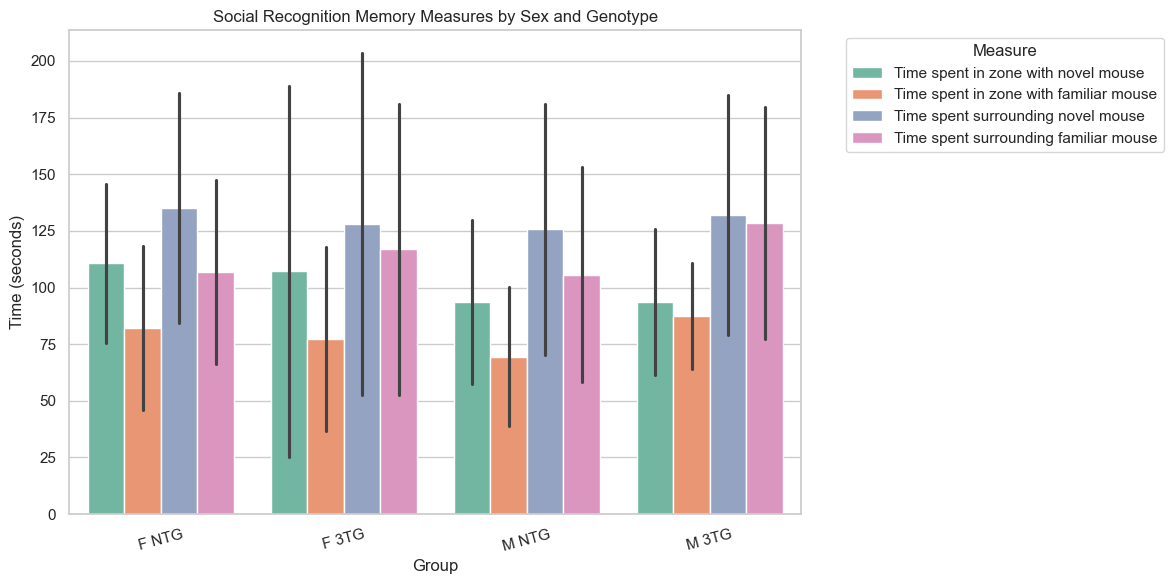

In [12]:
melted_group = prep_mem_measures_for_plotting(etho_3c_memory_df)
create_plot_social_memory_measures(melted_group, OUTPUT_DIR)

### 4.2. Plot mouse in zone with novel vs familiar mouse 

In [13]:
def prep_in_zone_plots(df):
    """
    Prepare time spent in the novel-mouse and familiar-mouse zones for plotting.

    Parameters:
    ### df [pandas.DataFrame]: DataFrame containing metadata and zone time measures for each mouse.

    Returns:
    ### df [pandas.DataFrame]: Long-format dataframe with group, measure, and time columns.
    """
    df = df.copy()

    # Combine Sex and Genotype into one column for grouping
    df['Group'] = df['Sex'].astype(str).str.capitalize() + ' ' + df['Genotype'].astype(str)

    # Select only the relevant columns
    cols_to_plot = [
        'Time spent in zone with novel mouse',
        'Time spent in zone with familiar mouse'
    ]
    # Ensure values are numeric
    df[cols_to_plot] = df[cols_to_plot].apply(pd.to_numeric, errors="coerce")

    # Melt the data
    melted_mouse_zone = pd.melt(
        df,
        id_vars=['Group'],
        value_vars=cols_to_plot,
        var_name='Measure',
        value_name='Time'
    )

    return melted_mouse_zone

def plot_zones(df, output_dir):
    """
    Plot time spent in the novel-mouse and familiar-mouse zones by group.

    Parameters:
    ### df [pandas.DataFrame]: Long-format dataframe containing group labels, time measures, and time values.

    Returns:
    ### None: Displays + saves the plot.
    """
    # Set style
    sns.set(style="whitegrid")

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df,
        x='Group', 
        y='Time', 
        hue='Measure',
        errorbar='sd',
        palette='Set1', 
        order = ["F NTG", "F 3TG", "M NTG", "M 3TG"]
    )
    plt.title('Time Spent in Zone with Novel vs. with Familiar by Group')
    plt.ylabel('Time (seconds)')
    plt.xlabel('Group')
    plt.xticks(rotation=15)
    plt.legend(title='Measure', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Save the plot 
    file_path_plot = os.path.join(output_dir, "day3_time_in_zone_novel_vs_familiar_by_group")
    plt.savefig(file_path_plot)

    # Show the plot 
    plt.show()

### 4.3. Generate in zone plots

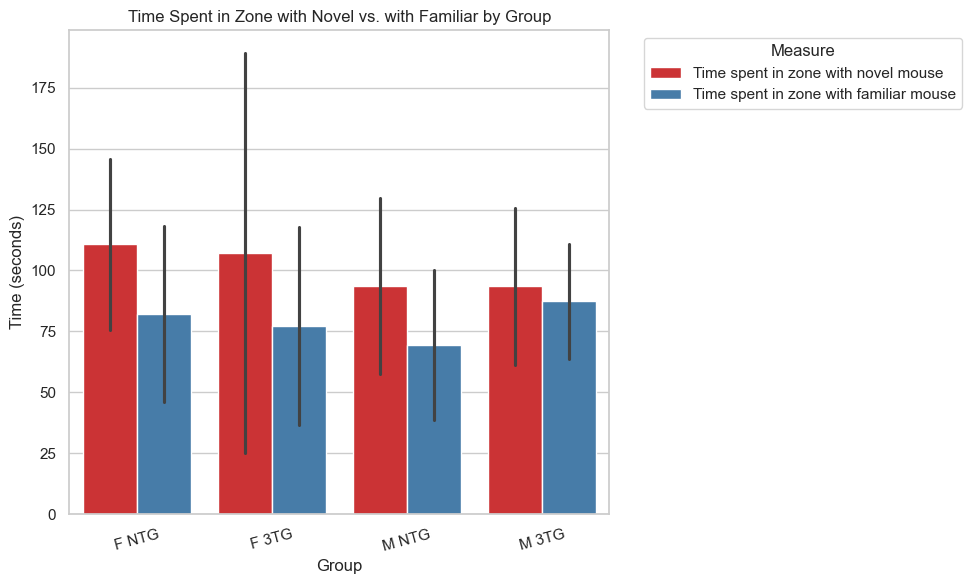

In [14]:
melted_mouse_zone = prep_in_zone_plots(etho_3c_memory_df)
plot_zones(melted_mouse_zone, OUTPUT_DIR)

### 4.4. Calculate average time spent in zone for each group

In zone with novel mouse

In [15]:
FNTg_novel_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone with novel mouse']
F3Tg_novel_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F 3TG'][melted_mouse_zone['Measure'] == 'Time spent in zone with novel mouse']
MNTg_novel_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'M NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone with novel mouse']
M3Tg_novel_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'M 3TG'][melted_mouse_zone['Measure'] == 'Time spent in zone with novel mouse']

/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_99153/2052598079.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  FNTg_novel_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone with novel mouse']
/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_99153/2052598079.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  F3Tg_novel_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F 3TG'][melted_mouse_zone['Measure'] == 'Time spent in zone with novel mouse']
/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_99153/2052598079.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  MNTg_novel_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'M NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone with novel mouse']
/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_99153/2052598079.py:4: 

In [16]:
avg_novel_mouse = [FNTg_novel_zone['Time'].mean(), F3Tg_novel_zone['Time'].mean(), MNTg_novel_zone['Time'].mean(), M3Tg_novel_zone['Time'].mean()]
print("average time spent investigating novel mouse cup (f Ntg, f 3xTg, m Ntg, m 3xTg):", avg_novel_mouse)

novel_zone_errors = [
    FNTg_novel_zone['Time'].std(ddof=1) / np.sqrt(FNTg_novel_zone['Time'].count()),
    F3Tg_novel_zone['Time'].std(ddof=1) / np.sqrt(F3Tg_novel_zone['Time'].count()),
    MNTg_novel_zone['Time'].std(ddof=1) / np.sqrt(MNTg_novel_zone['Time'].count()),
    M3Tg_novel_zone['Time'].std(ddof=1) / np.sqrt(M3Tg_novel_zone['Time'].count())
]
print("standard errors for average time spent with novel mouse (f Ntg, f 3xTg, m Ntg, m 3xTg):", novel_zone_errors)

average time spent investigating novel mouse cup (f Ntg, f 3xTg, m Ntg, m 3xTg): [110.65151515151516, 107.16060606060606, 93.7181818181818, 93.48333333333333]
standard errors for average time spent with novel mouse (f Ntg, f 3xTg, m Ntg, m 3xTg): [10.622441808381526, 24.699358278246994, 10.917606356629202, 9.325164625152485]


Results 
Average time spent investigating novel cup: 
- **f Ntg**: 110.65 ± 10.62
- **f 3xTg**: 107.16 ± 24.70
- **m Ntg**: 93.72 ± 10.92
- **m 3xTg**: 93.48 ± 9.33

In zone with familiar mouse

In [23]:
FNTg_familiar_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone with familiar mouse']
F3Tg_familiar_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F 3TG'][melted_mouse_zone['Measure'] == 'Time spent in zone with familiar mouse']
MNTg_familiar_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'M NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone with familiar mouse']
M3Tg_familiar_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'M 3TG'][melted_mouse_zone['Measure'] == 'Time spent in zone with familiar mouse']

/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_64469/4070930205.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  FNTg_familiar_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone with familiar mouse']
/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_64469/4070930205.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  F3Tg_familiar_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F 3TG'][melted_mouse_zone['Measure'] == 'Time spent in zone with familiar mouse']
/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_64469/4070930205.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  MNTg_familiar_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'M NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone with familiar mouse']
/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_64469

In [25]:
avg_familiar_mouse = [FNTg_familiar_zone['Time'].mean(), F3Tg_familiar_zone['Time'].mean(), MNTg_familiar_zone['Time'].mean(), M3Tg_familiar_zone['Time'].mean()]
print("average time spent investigating familiar mouse cup (f Ntg, f 3xTg, m Ntg, m 3xTg):", avg_familiar_mouse)

familiar_zone_errors = [
    FNTg_familiar_zone['Time'].std(ddof=1) / np.sqrt(FNTg_familiar_zone['Time'].count()),
    F3Tg_familiar_zone['Time'].std(ddof=1) / np.sqrt(F3Tg_familiar_zone['Time'].count()),
    MNTg_familiar_zone['Time'].std(ddof=1) / np.sqrt(MNTg_familiar_zone['Time'].count()),
    M3Tg_familiar_zone['Time'].std(ddof=1) / np.sqrt(M3Tg_familiar_zone['Time'].count())
]
print("standard errors for average time spent with familiar mouse (f Ntg, f 3xTg, m Ntg, m 3xTg):", familiar_zone_errors)

average time spent investigating familiar mouse cup (f Ntg, f 3xTg, m Ntg, m 3xTg): [82.1030303030303, 77.3090909090909, 69.54242424242425, 87.28333333333335]
standard errors for average time spent with familiar mouse (f Ntg, f 3xTg, m Ntg, m 3xTg): [10.897959640880106, 12.274822791544485, 9.290292632101673, 6.772649367956345]


Results 
Average time spent investigating familiar cup: 
- **f Ntg**: 82.10 ± 10.90
- **f 3xTg**: 77.31 ± 12.27
- **m Ntg**: 69.54 ± 9.29
- **m 3xTg**: 87.28 ± 6.77

## 5. Calculate a discrimination index for each mouse

In [17]:
etho_3c_memory_df = add_derived_measures(etho_3c_memory_df)

FNTg_subset = etho_3c_memory_df[etho_3c_memory_df['Group'] == 'F NTG']
F3Tg_subset = etho_3c_memory_df[etho_3c_memory_df['Group'] == 'F 3TG']
MNTg_subset = etho_3c_memory_df[etho_3c_memory_df['Group'] == 'M NTG']
M3Tg_subset = etho_3c_memory_df[etho_3c_memory_df['Group'] == 'M 3TG']

## 6. Calculate average discrimination index

In [18]:
# Calculate the average discrimination index for each genotype
average_discrimination_index = [FNTg_subset['discrimination index'].mean(), F3Tg_subset['discrimination index'].mean(), MNTg_subset['discrimination index'].mean(), M3Tg_subset['discrimination index'].mean()]
print('Average discrimination index for each group (f Ntg, f 3xTg, m Ntg, m 3xTg', average_discrimination_index)

# Calculate SEM error bars 
discrimination_errors = [
    FNTg_subset['discrimination index'].std(ddof=1) / np.sqrt(FNTg_subset['discrimination index'].count()),
    F3Tg_subset['discrimination index'].std(ddof=1) / np.sqrt(F3Tg_subset['discrimination index'].count()),
    MNTg_subset['discrimination index'].std(ddof=1) / np.sqrt(MNTg_subset['discrimination index'].count()),
    M3Tg_subset['discrimination index'].std(ddof=1) / np.sqrt(M3Tg_subset['discrimination index'].count())
]
print('SEM of discrimination index for each group (f Ntg, f 3xTg, m Ntg, m 3xTg', discrimination_errors)

# Calculate the average total investigation time for each genotype
average_total_investigation_time = [FNTg_subset['total investigation time'].mean(), F3Tg_subset['total investigation time'].mean(), MNTg_subset['total investigation time'].mean(), M3Tg_subset['total investigation time'].mean()]
print('Average total investigation time for each group (f Ntg, f 3xTg, m Ntg, m 3xTg', average_total_investigation_time)

# Calculate SEM error bars 
investigation_time_errors = [
    FNTg_subset['total investigation time'].std(ddof=1) / np.sqrt(FNTg_subset['total investigation time'].count()),
    F3Tg_subset['total investigation time'].std(ddof=1) / np.sqrt(F3Tg_subset['total investigation time'].count()),
    MNTg_subset['total investigation time'].std(ddof=1) / np.sqrt(MNTg_subset['total investigation time'].count()),
    M3Tg_subset['total investigation time'].std(ddof=1) / np.sqrt(M3Tg_subset['total investigation time'].count())
]
print('SEM of total investigation time for each group (f Ntg, f 3xTg, m Ntg, m 3xTg', investigation_time_errors)

Average discrimination index for each group (f Ntg, f 3xTg, m Ntg, m 3xTg [0.1574258648434199, 0.05144697583823579, 0.14977557038160583, 0.021843472297858744]
SEM of discrimination index for each group (f Ntg, f 3xTg, m Ntg, m 3xTg [0.09019551941464068, 0.15036241475086254, 0.0729570129858536, 0.06389364474605158]
Average total investigation time for each group (f Ntg, f 3xTg, m Ntg, m 3xTg [192.75454545454548, 184.46969696969697, 163.26060606060605, 180.76666666666668]
SEM of total investigation time for each group (f Ntg, f 3xTg, m Ntg, m 3xTg [15.223941984586187, 22.369410685917984, 13.629843828582626, 10.875762289936526]


Results for average discrimination index
- **f Ntg**: 0.15 ± 0.09
- **f 3xTg**: 0.05 ± 0.15
- **m Ntg**: 0.15 ± 0.07
- **m 3xTg**: 0.02 ± 0.06

Results for average total investigation time 
- **f Ntg**: 192.75 ± 15.22
- **f 3xTg**: 184.47 ± 22.37
- **m Ntg**: 163.26 ± 13.63
- **m 3xTg**: 180.77 ± 10.88

Average for the 3xTg mice 

In [19]:
trans_subset = etho_3c_memory_df[etho_3c_memory_df['Genotype'] == '3TG']
avg_trans_index = trans_subset['discrimination index'].mean()
print("average discrimination index for 3xTg", avg_trans_index)
trans_error_di= trans_subset['discrimination index'].std(ddof=1) / np.sqrt(trans_subset['discrimination index'].count())
print("SEM of discrimination index for 3xTg", trans_error_di)

average discrimination index for 3xTg 0.03600166964325645
SEM of discrimination index for 3xTg 0.07739432724703112


Average for control mice

In [20]:
control_subset = etho_3c_memory_df[etho_3c_memory_df['Genotype'] == 'NTG']
avg_control_index = control_subset['discrimination index'].mean()
print("average discrimination index for Ntg (control):", avg_control_index)
control_error_di= control_subset['discrimination index'].std(ddof=1) / np.sqrt(control_subset['discrimination index'].count())
print("SEM of discrimination index for Ntg (control):", control_error_di)

average discrimination index for Ntg (control): 0.15360071761251282
SEM of discrimination index for Ntg (control): 0.05661247510290267


Average total investigation time for 3xTg vs Ntg

In [21]:
# 3xTg
avg_trans_tit = trans_subset['total investigation time'].mean()
print("Average total investigation time for 3xTg:", avg_trans_tit)
trans_error_tit= trans_subset['total investigation time'].std(ddof=1) / np.sqrt(trans_subset['total investigation time'].count())
print("SEM of total investigation time for 3xTg:", trans_error_tit)

# Ntg
avg_control_tit = control_subset['total investigation time'].mean()
print("Average total investigation time for Ntg (control):", avg_control_tit)
control_error_tit= control_subset['total investigation time'].std(ddof=1) / np.sqrt(control_subset['total investigation time'].count())
print("SEM of total investigation time for Ntg (control):", control_error_tit)

Average total investigation time for 3xTg: 182.5376811594203
SEM of total investigation time for 3xTg: 11.823379677654218
Average total investigation time for Ntg (control): 178.00757575757572
SEM of total investigation time for Ntg (control): 10.477136961138017


Average investigation time of novel cup 3xTg vs control

In [38]:
# 3xTg
trans_novel_it = trans_subset['Time spent in zone with novel mouse'].mean()
trans_novel_error= trans_subset['Time spent in zone with novel mouse'].std(ddof=1) / np.sqrt(trans_subset['Time spent in zone with novel mouse'].count())
print(f"Average investigation time of novel cup for 3xTg: {trans_novel_it} ± {trans_novel_error}")


# Ntg (control)
control_novel_it = control_subset['Time spent in zone with novel mouse'].mean()
control_novel_error= control_subset['Time spent in zone with novel mouse'].std(ddof=1) / np.sqrt(control_subset['Time spent in zone with novel mouse'].count())
print(f"Average investigation time of novel cup for Ntg (control): {control_novel_it} ± {control_novel_error}")

Average investigation time of novel cup for 3xTg: 100.02463768115942 ± 12.547031454478814
Average investigation time of novel cup for Ntg (control): 102.1848484848485 ± 7.658908405057456


Average investigation time of familiar cup 3xTg vs control

In [39]:
# 3xTg
trans_familiar_it = trans_subset['Time spent in zone with familiar mouse'].mean()
trans_familiar_error= trans_subset['Time spent in zone with familiar mouse'].std(ddof=1) / np.sqrt(trans_subset['Time spent in zone with familiar mouse'].count())
print(f"Average investigation time of familiar cup for 3xTg: {trans_familiar_it} ± {trans_familiar_error}")


# Ntg (control)
control_familiar_it = control_subset['Time spent in zone with familiar mouse'].mean()
control_familiar_error= control_subset['Time spent in zone with familiar mouse'].std(ddof=1) / np.sqrt(control_subset['Time spent in zone with familiar mouse'].count())
print(f"Average investigation time of familiar cup for Ntg (control): {control_familiar_it} ± {control_familiar_error}")

Average investigation time of familiar cup for 3xTg: 82.51304347826085 ± 6.771172243997719
Average investigation time of familiar cup for Ntg (control): 75.82272727272726 ± 7.120786185106597


## 7. Visualize findings

In [22]:
def plot_si_and_tit(avg_di, di_errors, avg_tit, tit_errors, output_dir): 
    """
    Plot average sociability index and total investigation time by group.

    Parameters:
    ### avg_di [list]: Average discrimination index values for each group.
    ### di_errors list]: Error values for the discrimination index bars.
    ### avg_tit [list]: Average total investigation time values for each group.
    ### tit_errors [list]: Error values for the total investigation time bars.
    ### output_dir [str]: Directory where the plot should be saved.

    Returns:
    ### None: function saves and shows plot
    """
    groups = ["F NTG", "F 3TG", "M NTG", "M 3TG"]
    colors = ["#A991D4", "#7AC5CD", "#FDB462", "#8DD3C7"] # lilac, turquoise, soft orange, soft green

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].bar(
        groups,
        avg_di,
        yerr=di_errors,
        capsize=5,
        color=colors,
    )
    axes[0].set_xlabel("Genotype & Sex")
    axes[0].set_ylabel("Average social novelty index")
    axes[0].set_title("Social Novelty Index - Day 3")

    axes[1].bar(
        groups,
        avg_tit,
        yerr=tit_errors,
        capsize=5,
        color=colors,
    )
    axes[1].set_xlabel("Genotype & Sex")
    axes[1].set_ylabel("Average total investigation time")
    axes[1].set_title("Total investigation time - Day 3")

    plt.tight_layout()

    file_path_plot = os.path.join(
        output_dir,
        "day3_discrimination_index_and_total_investigation_time",
    )

    plt.savefig(file_path_plot)
    plt.show()
    plt.close()

### 7.1. Generate the plots

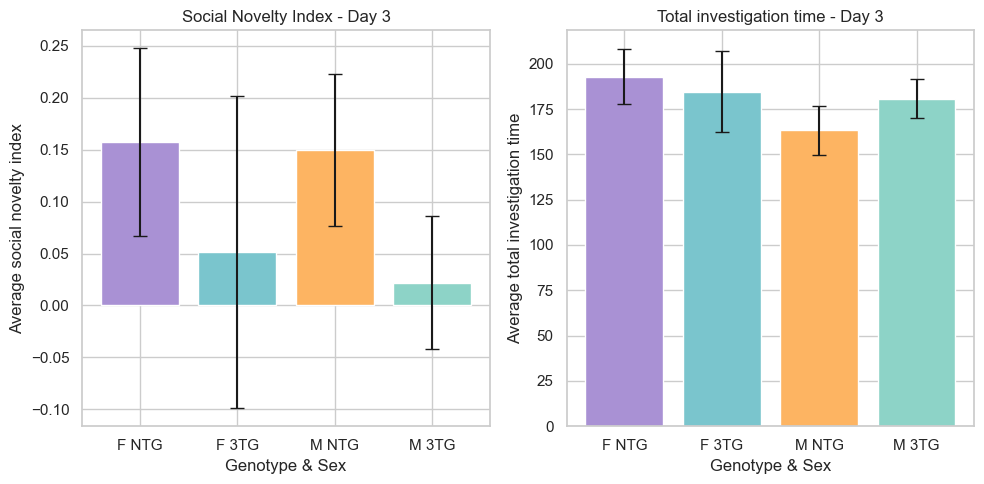

In [23]:
plot_si_and_tit(average_discrimination_index, discrimination_errors, average_total_investigation_time, investigation_time_errors, OUTPUT_DIR)

## 8. Perform statistical analyses

### 8.1. Inspect group sizes

In [43]:
display(etho_3c_memory_df.groupby("Group").size().rename("n").reset_index())

,Group,n
0,F 3TG,11
1,F NTG,11
2,M 3TG,12
3,M NTG,11


### 8.2. Check statistical assumptions for discrimination index

#### 8.2.1. Test normality using Shapiro-Wilk test

In [44]:
for group, subset in etho_3c_memory_df.groupby(["Genotype", "Sex"]):
    stat, p = stats.shapiro(subset["discrimination index"])
    print(group, p)

('3TG', 'F') 0.8700649131428942
('3TG', 'M') 0.6365312031525953
('NTG', 'F') 0.7571032293776288
('NTG', 'M') 0.9973220916725887


All groups were normally distributed according to the Shapiro-Wilk test, as all p-values were greater than 0.05.

#### QQ plots

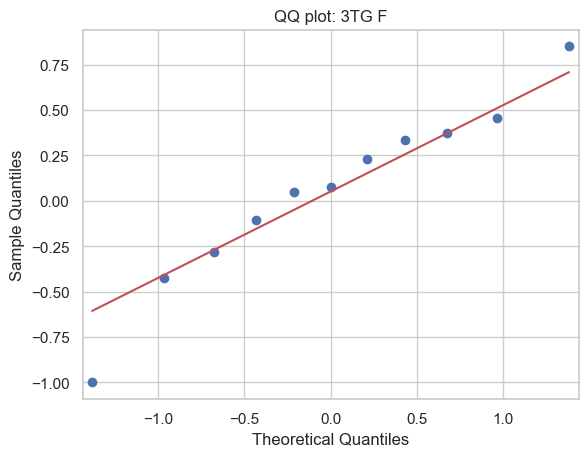

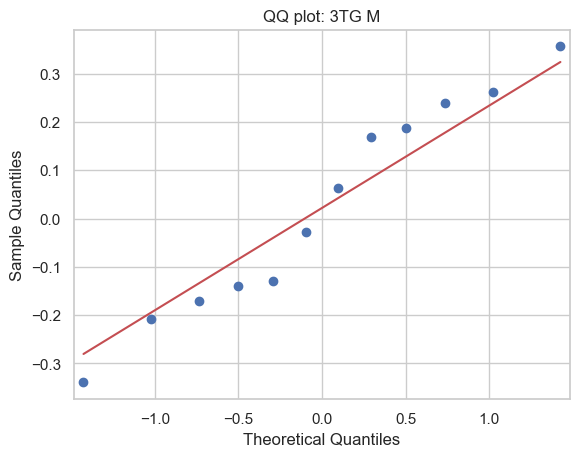

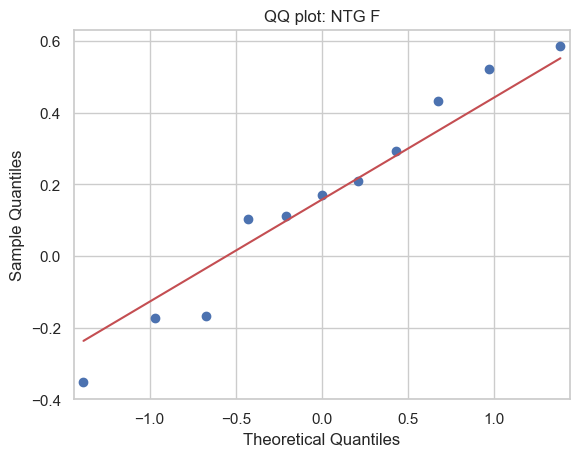

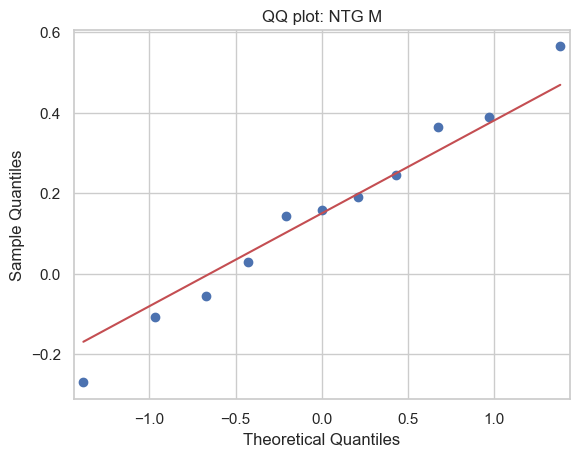

In [45]:
groups = etho_3c_memory_df.groupby(["Genotype", "Sex"])

for (genotype, sex), subset in groups:
    data = subset["discrimination index"].dropna()

    sm.qqplot(data, line="s")
    plt.title(f"QQ plot: {genotype} {sex}")
    file_path_plot = os.path.join(OUTPUT_DIR, f"qq plots day3 DI {genotype} {sex}")
    plt.savefig(file_path_plot)
    plt.show()

#### 8.2.2. Test homogeneity of variance using Levene's test

In [46]:
stats.levene(
    etho_3c_memory_df[(etho_3c_memory_df.Genotype=="NTG") & (etho_3c_memory_df.Sex=="M")]["discrimination index"],
    etho_3c_memory_df[(etho_3c_memory_df.Genotype=="NTG") & (etho_3c_memory_df.Sex=="F")]["discrimination index"],
    etho_3c_memory_df[(etho_3c_memory_df.Genotype=="3TG") & (etho_3c_memory_df.Sex=="M")]["discrimination index"],
    etho_3c_memory_df[(etho_3c_memory_df.Genotype=="3TG") & (etho_3c_memory_df.Sex=="F")]["discrimination index"]
)

LeveneResult(statistic=1.9299934918259285, pvalue=0.1398013591008161)

The assumption of equal variances was met according to Levene’s test, as p > 0.05.

### 8.2. Perform two-way ANOVA on discrimination index 

In [47]:
model_di = smf.ols("Q('discrimination index') ~ C(Genotype) * C(Sex)", data=etho_3c_memory_df).fit()
anova_table_di = sm.stats.anova_lm(model_di, typ=2)

print(anova_table_di)

                      sum_sq    df         F    PR(>F)
C(Genotype)         0.154350   1.0  1.404357  0.242819
C(Sex)              0.003998   1.0  0.036375  0.849684
C(Genotype):C(Sex)  0.001354   1.0  0.012315  0.912178
Residual            4.506226  41.0       NaN       NaN


Results show no significant differences

### 8.3. Check statistical assumptions for total investigation time

#### 8.3.1. Test normality using Shapiro-Wilk test

In [48]:
for group, subset in etho_3c_memory_df.groupby(["Genotype", "Sex"]):
    stat, p = stats.shapiro(subset["total investigation time"])
    print(group, p)

('3TG', 'F') 0.3288242077253554
('3TG', 'M') 0.14773340856559963
('NTG', 'F') 0.3404174692140598
('NTG', 'M') 0.3638496008988218


All groups were normally distributed according to the Shapiro-Wilk test, as all p-values were greater than 0.05.

#### QQ Plots

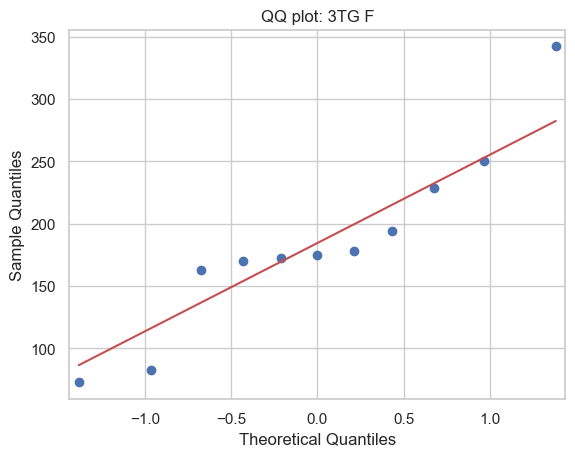

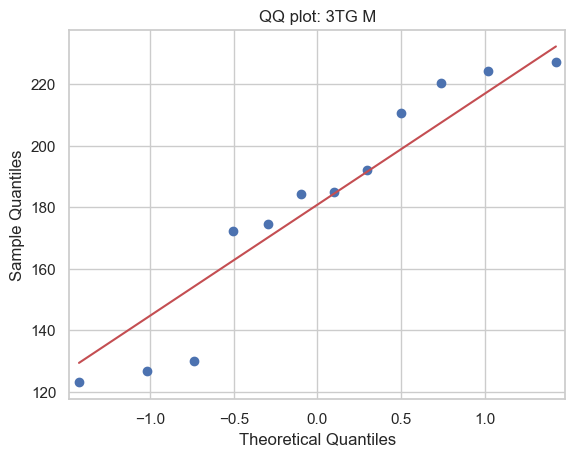

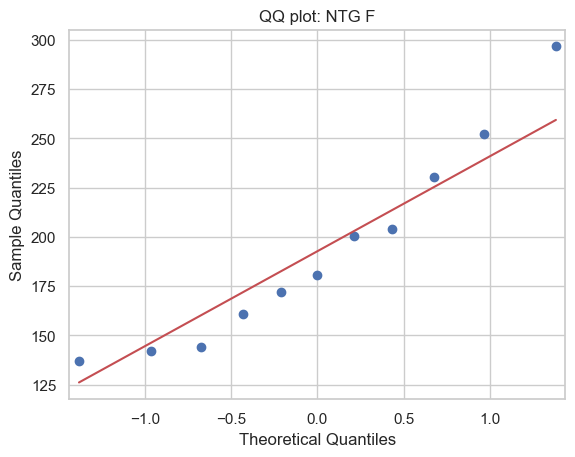

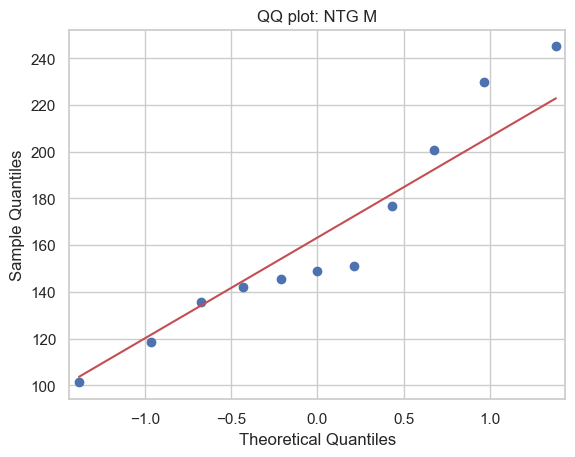

In [50]:
groups = etho_3c_memory_df.groupby(["Genotype", "Sex"])

for (genotype, sex), subset in groups:
    data = subset["total investigation time"].dropna()

    sm.qqplot(data, line="s")
    plt.title(f"QQ plot: {genotype} {sex}")
    file_path_plot = os.path.join(OUTPUT_DIR, f"qq plots d3 {genotype} {sex} tit")
    plt.savefig(file_path_plot)
    plt.show()

#### 8.3.2. Check homogeneity of variance using Levene's test

In [51]:
# Levene 
stats.levene(
    etho_3c_memory_df[(etho_3c_memory_df.Genotype=="NTG") & (etho_3c_memory_df.Sex=="M")]["total investigation time"],
    etho_3c_memory_df[(etho_3c_memory_df.Genotype=="NTG") & (etho_3c_memory_df.Sex=="F")]["total investigation time"],
    etho_3c_memory_df[(etho_3c_memory_df.Genotype=="3TG") & (etho_3c_memory_df.Sex=="M")]["total investigation time"],
    etho_3c_memory_df[(etho_3c_memory_df.Genotype=="3TG") & (etho_3c_memory_df.Sex=="F")]["total investigation time"]
)

LeveneResult(statistic=0.5778774518092664, pvalue=0.6328487485176189)

The assumption of equal variances was met according to Levene’s test, as p > 0.05.

### 8.3. Perform two-way ANOVA on total investigation time

In [52]:
model_tit = smf.ols("Q('total investigation time') ~ C(Genotype) * C(Sex)", 
    data=etho_3c_memory_df
).fit()
anova_table_tit = sm.stats.anova_lm(model_tit, typ=2)

print(anova_table_tit)

                           sum_sq    df         F    PR(>F)
C(Genotype)            268.199420   1.0  0.094318  0.760312
C(Sex)                2994.966173   1.0  1.053247  0.310777
C(Genotype):C(Sex)    1868.139807   1.0  0.656973  0.422310
Residual            116585.725657  41.0       NaN       NaN


No significant differences

### 8.4. Perform two-way ANOVA on investigation time of each cup

#### 8.4.1. Novel cup investigation

In [54]:
model_with_novel = smf.ols(
    'Q("Time spent in zone with novel mouse") ~ C(Genotype) * C(Sex)',
    data=etho_3c_memory_df
).fit()
anova_table_with_novel = sm.stats.anova_lm(model_with_novel, typ=2)

print(anova_table_with_novel)

                           sum_sq    df         F    PR(>F)
C(Genotype)             37.566354   1.0  0.014794  0.903784
C(Sex)                2620.888585   1.0  1.032160  0.315610
C(Genotype):C(Sex)      29.775635   1.0  0.011726  0.914296
Residual            104108.304545  41.0       NaN       NaN


No significant differences

#### 8.4.2. Familiar cup investigation

In [55]:
model_with_familiar = smf.ols(
    'Q("Time spent in zone with familiar mouse") ~ C(Genotype) * C(Sex)',
    data=etho_3c_memory_df
).fit()
anova_table_with_familiar = sm.stats.anova_lm(model_with_familiar, typ=2)

print(anova_table_with_familiar)

                          sum_sq    df         F    PR(>F)
C(Genotype)           506.517108   1.0  0.459586  0.501626
C(Sex)                 12.472688   1.0  0.011317  0.915798
C(Genotype):C(Sex)   1426.216177   1.0  1.294070  0.261904
Residual            45186.775859  41.0       NaN       NaN


No significant differences

### 8.5. Calculate effect sizes

#### 8.5.1. Of discrimination index

In [56]:
# DI
anova_di = sm.stats.anova_lm(model_di, typ=2)

ss_res = anova_di.loc["Residual", "sum_sq"]

anova_di["partial_eta_sq"] = (
    anova_di["sum_sq"] /
    (anova_di["sum_sq"] + ss_res)
)

anova_di["partial_eta_sq"] = np.nan

ss_res = anova_di.loc["Residual", "sum_sq"]

for effect in ["C(Genotype)", "C(Sex)", "C(Genotype):C(Sex)"]:
    anova_di.loc[effect, "partial_eta_sq"] = (
        anova_di.loc[effect, "sum_sq"] /
        (anova_di.loc[effect, "sum_sq"] + ss_res)
    )

print("discrimination index")
print(anova_di)

discrimination index
                      sum_sq    df         F    PR(>F)  partial_eta_sq
C(Genotype)         0.154350   1.0  1.404357  0.242819        0.033118
C(Sex)              0.003998   1.0  0.036375  0.849684        0.000886
C(Genotype):C(Sex)  0.001354   1.0  0.012315  0.912178        0.000300
Residual            4.506226  41.0       NaN       NaN             NaN


#### 8.5.1. Of total investigation time

In [57]:
# total investigation time 
anova_tit = sm.stats.anova_lm(model_tit, typ=2)

ss_res = anova_tit.loc["Residual", "sum_sq"]

anova_tit["partial_eta_sq"] = (
    anova_tit["sum_sq"] /
    (anova_tit["sum_sq"] + ss_res)
)

anova_tit["partial_eta_sq"] = np.nan

ss_res = anova_tit.loc["Residual", "sum_sq"]

for effect in ["C(Genotype)", "C(Sex)", "C(Genotype):C(Sex)"]:
    anova_tit.loc[effect, "partial_eta_sq"] = (
        anova_tit.loc[effect, "sum_sq"] /
        (anova_tit.loc[effect, "sum_sq"] + ss_res)
    )


print("total investigation time:")
print(anova_tit)

total investigation time:
                           sum_sq    df         F    PR(>F)  partial_eta_sq
C(Genotype)            268.199420   1.0  0.094318  0.760312        0.002295
C(Sex)                2994.966173   1.0  1.053247  0.310777        0.025046
C(Genotype):C(Sex)    1868.139807   1.0  0.656973  0.422310        0.015771
Residual            116585.725657  41.0       NaN       NaN             NaN
